In [1]:
import numpy as np

from pymoo.problems import get_problem
from pymoo.visualization.fitness_landscape import FitnessLandscape
import pandas as pd
import seaborn as sns
import os

In [2]:
from pymoo.core.problem import Problem
def get_bbob(name, n_var=10, **kwargs):
    try:
        import cocoex as ex
    except:
        raise Exception("COCO test suite not found. \nInstallation Guide: https://github.com/numbbo/coco")

    args = name.split("-")
    suite = args[0]
    n_instance = int(args[2])
    n_function = int(args[1].replace("f", ""))

    assert 1 <= n_function <= 24, f"BBOB has 24 different functions to be chosen. {n_function} is out of range."

    suite_filter_options = f"function_indices: {n_function} " \
                           f"instance_indices: {n_instance} " \
                           f"dimensions: {n_var}"

    problems = ex.Suite(suite, "instances: 1-999", suite_filter_options)
    assert len(problems) == 1, "COCO problem not found."

    coco = problems.next_problem()

    return n_function, n_instance, coco
class BBOBProblem(Problem):

    def __init__(self, name, n_var, pf_from_file=True, **kwargs):
        self.function, self.instance, self.object = get_bbob(name, n_var)
        self.name = name
        self.pf_from_file = pf_from_file

        coco = self.object
        n_var, n_obj, n_ieq_constr = coco.number_of_variables, coco.number_of_objectives, coco.number_of_constraints
        xl, xu = coco.lower_bounds, coco.upper_bounds

        super().__init__(n_var=n_var,
                         n_obj=n_obj,
                         n_ieq_constr=n_ieq_constr,
                         xl=xl,
                         xu=xu,
                         **kwargs)

    def _calc_pareto_set(self, *args, **kwargs):
        if self.n_obj == 1:
            fname = '._bbob_problem_best_parameter.txt'

            self.object._best_parameter(what="print")
            ps = np.loadtxt(fname)
            os.remove(fname)

            return ps

    def _calc_pareto_front(self, *args, **kwargs):
        if self.pf_from_file:
            return Remote.get_instance().load("pymoo", "pf", "bbob.pf", to="json")[str(self.function)][str(self.instance)]
        else:
            ps = self.pareto_set()
            if ps is not None:
                return self.evaluate(ps)

    def _evaluate(self, X, out, *args, **kwargs):
        out["F"] = np.array([self.object(x) for x in X])
        return out
    
    def evaluate_basic(self, x, *args, **kwargs):
        return self.object(x)

    def __getstate__(self):
        d = self.__dict__.copy()
        d["object"] = None
        return d

    def __setstate__(self, d):
        self.__dict__.update(d)
        self.object = get_bbob(self.name, self.n_var)
        

In [33]:
problem_id=20
instance_id=3
dim=2
p=BBOBProblem(f'bbob-{problem_id}-{instance_id}',dim)

In [34]:
from ioh import get_problem, ProblemClass
f = get_problem(problem_id, instance_id, dim, ProblemClass.BBOB)
d=pd.read_csv(f'data/processed/dim_{dim}/F{problem_id}_I{instance_id}.csv',compression='zip',index_col=0)
d['raw_y']=d['raw_y']+f.optimum.y

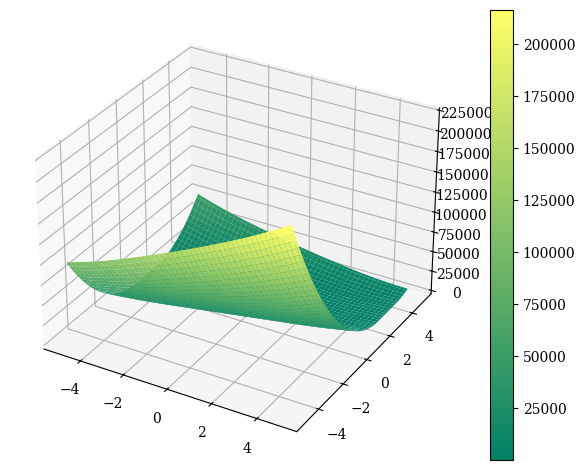

AugmentedAEO 1


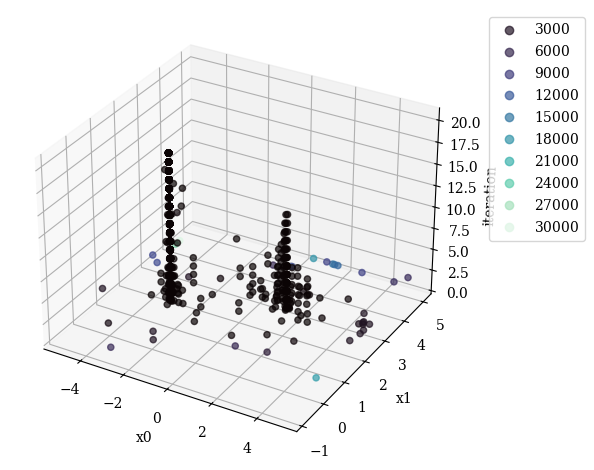

OriginalSHADE 1


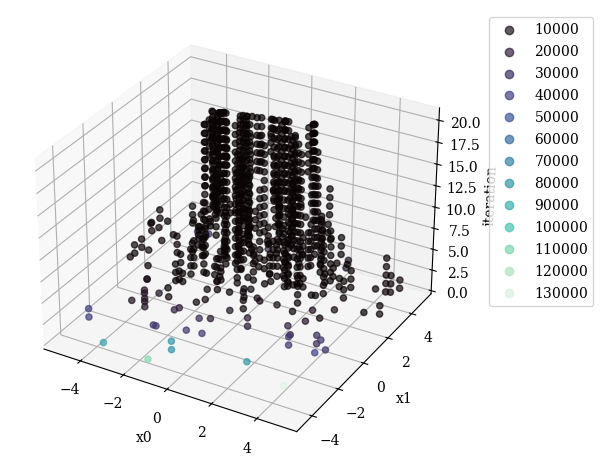

OriginalAEO 1


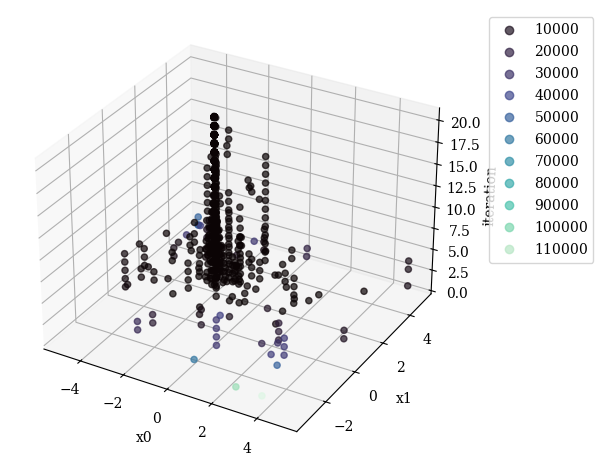

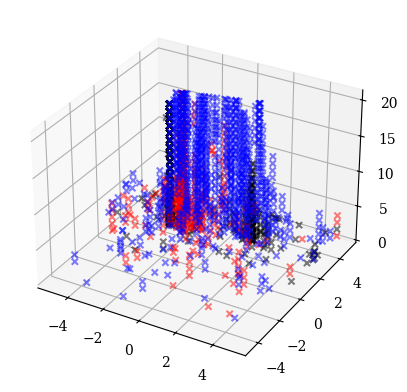

In [35]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def all_combinations(A, B):
    grid = np.meshgrid(A, B)
    return np.column_stack([g.ravel() for g in grid])

problem=p
scatter_df=d.query('algorithm in ["AugmentedAEO","OriginalAEO","OriginalSHADE"] and run==1')
#scatter_df=d.query('algorithm in ["OriginalSBO",	"OriginalBFO",	"OriginalFPA", "OriginalNMRA" ] and run==0')
#scatter_df=d.query('algorithm in ["BaseDE",	"SADE",	"BaseGA" ] and run==0')
#scatter_df=d.query('algorithm in ["AugmentedAEO", "BaseDE"]')
color_column='algorithm'
n_samples=100
A = np.linspace(problem.xl[0], problem.xu[0], n_samples)
B = np.linspace(problem.xl[1], problem.xu[1], n_samples)
X = all_combinations(A, B)

F = np.reshape(problem.evaluate(X, return_values_of=["F"]), (n_samples, n_samples))

_X = X[:, 0].reshape((n_samples, n_samples))
_Y = X[:, 1].reshape((n_samples, n_samples))
_Z = F.reshape((n_samples, n_samples))

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(_X, _Y, _Z, cmap="summer", alpha=1)
plt.tight_layout()
plt.savefig(f'figures_clustering_new_kmeans/surface_bbob-{problem_id}-{instance_id}.pdf',bbox_inches='tight',pad_inches=0)
fig.colorbar(surf)
plt.show()
colors = ['black','blue',"red",'yellow']



# get colormap from seaborn
cmap = ListedColormap(sns.color_palette("mako", 256).as_hex())
for id, c_v in enumerate(scatter_df[color_column].unique()):
    for run in scatter_df['run'].unique():
        fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
        to_plot=scatter_df[scatter_df[color_column]==c_v]
        to_plot=to_plot.query('run==@run')
        sc=ax.scatter(to_plot['x0'], to_plot['x1'], to_plot['iteration'],c=to_plot['raw_y'], zorder=500, alpha=0.7, cmap=cmap)
        ax.set_xlabel('x0')
        ax.set_ylabel('x1')
        ax.set_zlabel('iteration')
        plt.legend(*sc.legend_elements(), bbox_to_anchor=(1.05, 1), loc=2)
        plt.tight_layout()
        plt.savefig(f'figures_clustering_new_kmeans/scatterplot_bbob-{problem_id}-{instance_id}_{c_v}_run_{run}.pdf',bbox_inches='tight',pad_inches=0)
        print(c_v, run)
        plt.show()

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
for id, c_v in enumerate(scatter_df[color_column].unique()):
    to_plot=scatter_df[scatter_df[color_column]==c_v]
    
    ax.scatter(to_plot['x0'], to_plot['x1'], to_plot['iteration'], color=colors[id], marker='x',zorder=500, alpha=0.5)
plt.savefig(f'figures_clustering_new_kmeans/scatterplot_bbob-{problem_id}-{instance_id}.pdf',bbox_inches='tight',pad_inches=0)
plt.show()

/tmp/ipykernel_261373/2650334941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['color']=to_plot['algorithm'].apply(lambda x: 'b.' if x=="HI_WOA" else 'red')


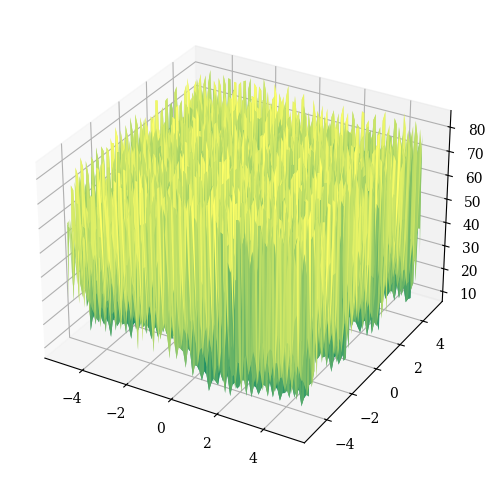

In [12]:
to_plot=d.query('algorithm=="HI_WOA" and run==1')
to_plot['color']=to_plot['algorithm'].apply(lambda x: 'b.' if x=="HI_WOA" else 'red')
x=FitnessLandscape(p, angle=(0, 0), _type="surface", scatter_x=to_plot['x0'],scatter_y=to_plot['x1'],scatter_z=to_plot['raw_y'], scatter_color=list(to_plot['color'].values) )
#sns.scatterplot(d.query('run==0 and iteration==0 and algorithm in ["LevyTWO","OriginalHC"]'), x='x0', y='x1', hue="algorithm",  palette='mako')
x.show()

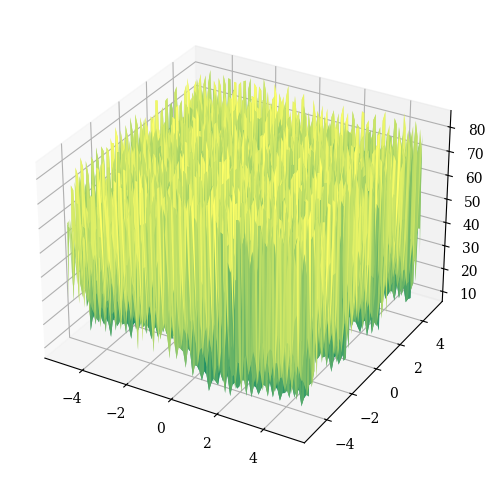

In [13]:
to_plot=d.query('algorithm=="OriginalWOA" and run==1')
x=FitnessLandscape(p, angle=(0, 0), _type="surface", scatter_x=to_plot['x0'],scatter_y=to_plot['x1'],scatter_z=to_plot['raw_y'] )
#sns.scatterplot(d.query('run==0 and iteration==0 and algorithm in ["LevyTWO","OriginalHC"]'), x='x0', y='x1', hue="algorithm",  palette='mako')
x.show()

In [42]:
d = pd.read_parquet('data/clustering_features_10_algorithms_dbscan/clustering_results/dim_2/F16_I3.parquet')
print(d.head(10))
print(d.columns.tolist())
print(d.shape)
pts_in_cluster = d.groupby(['cluster']).size()
print(pts_in_cluster)
problem = get_problem(16, 3, 2, ProblemClass.BBOB)
opt_x = problem.optimum.x
opt_y = problem.optimum.y
print(opt_x, opt_y)

              x0        x1       raw_y  iteration  evaluations   algorithm  \
285000 -3.965921  2.923508  109.443037        1.0         50.0  OriginalDE   
285001 -1.399637  2.623700  113.545018        1.0         50.0  OriginalDE   
285002 -4.180161  2.735219  140.847946        1.0         50.0  OriginalDE   
285003 -4.084920 -2.668725  116.090212        1.0         50.0  OriginalDE   
285004  5.000000  0.052327  137.380045        1.0         50.0  OriginalDE   
285005 -1.296003 -3.433241  115.670021        1.0         50.0  OriginalDE   
285006 -2.147709  4.179195  168.535167        1.0         50.0  OriginalDE   
285007 -1.795579 -4.420298  135.579996        1.0         50.0  OriginalDE   
285008  0.376259  3.693330  129.578909        1.0         50.0  OriginalDE   
285009 -4.105946 -3.487088  141.224348        1.0         50.0  OriginalDE   

        run  problem_id  instance_id  scaled_x0  scaled_x1  scaled_raw_y  \
285000    1          16            3   0.103408   0.792351      0

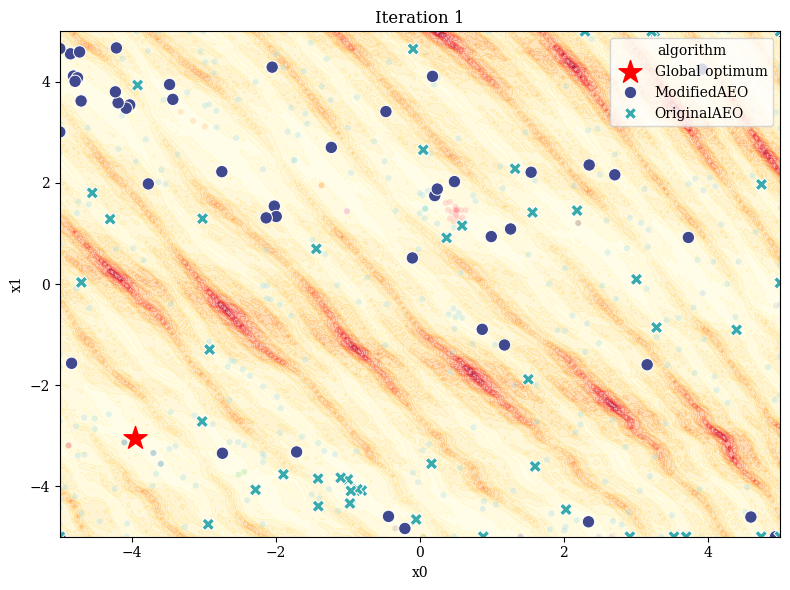

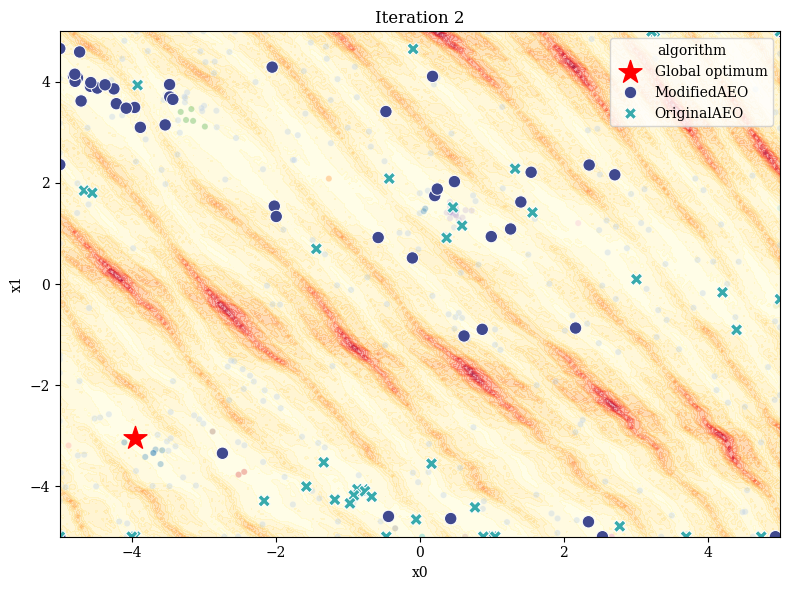

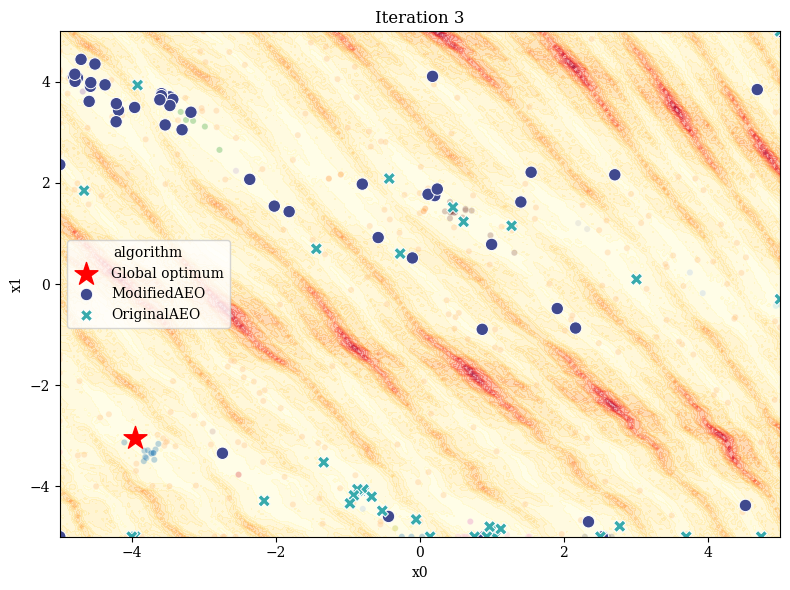

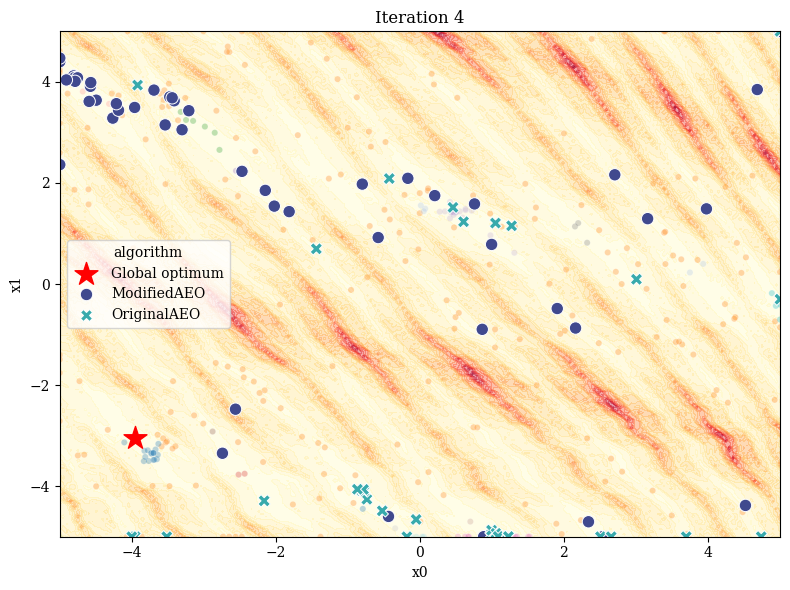

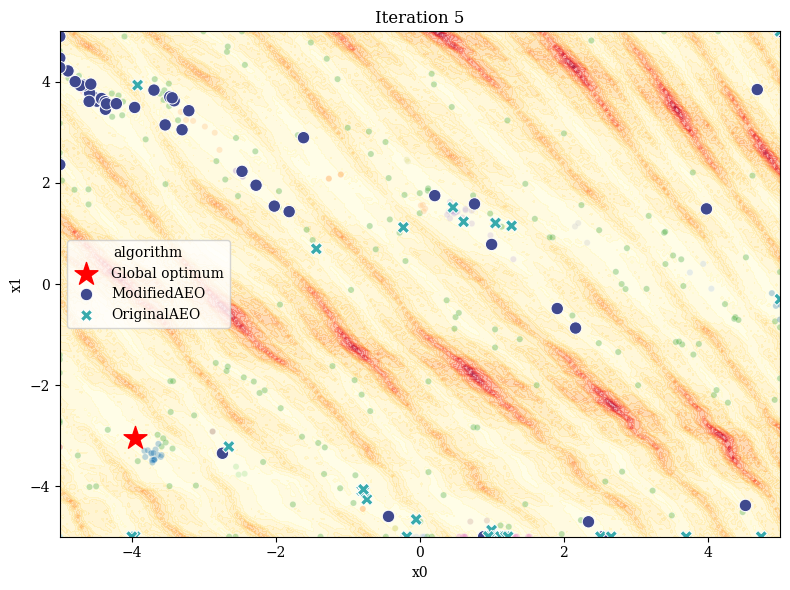

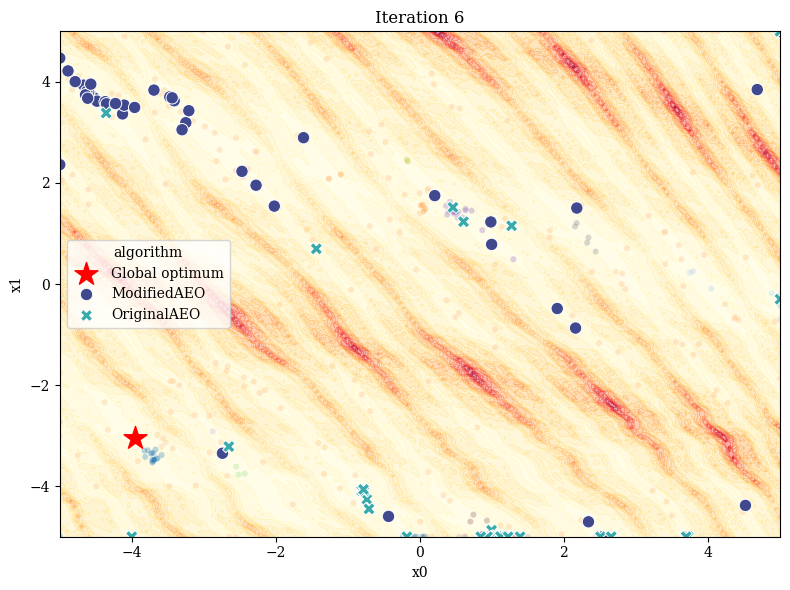

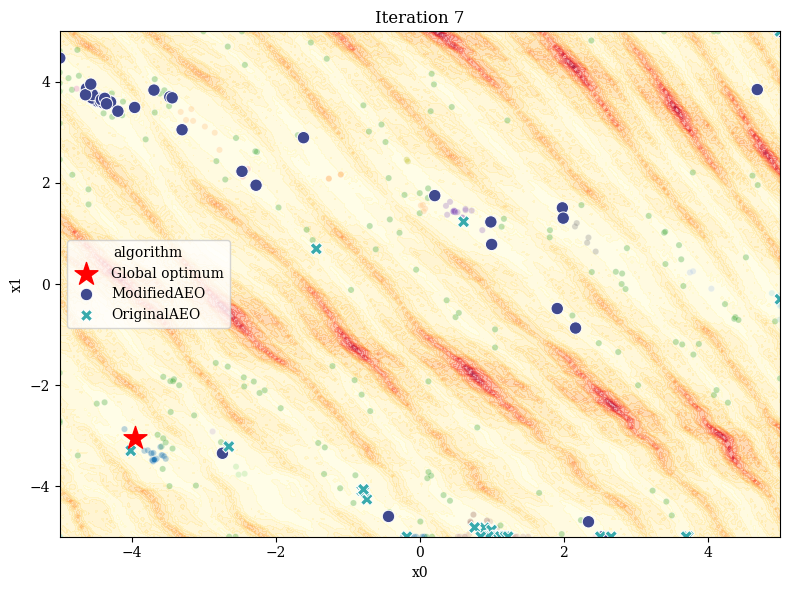

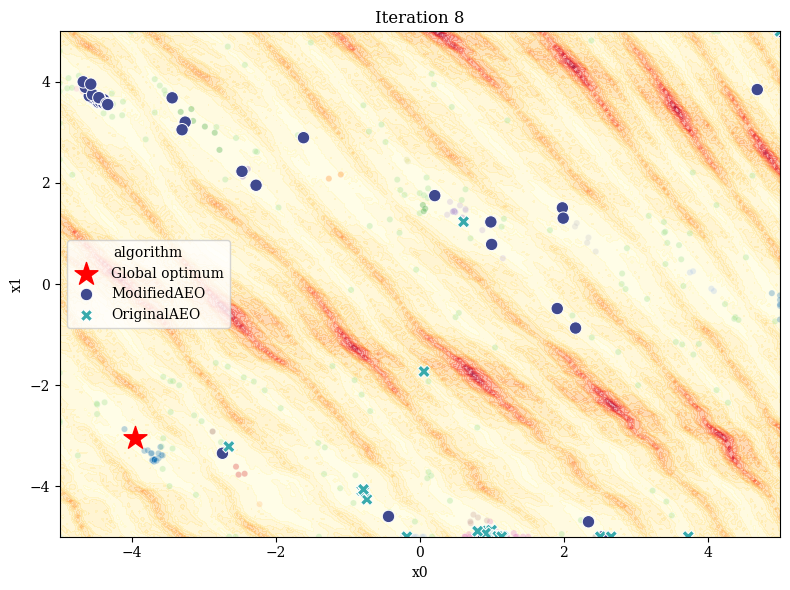

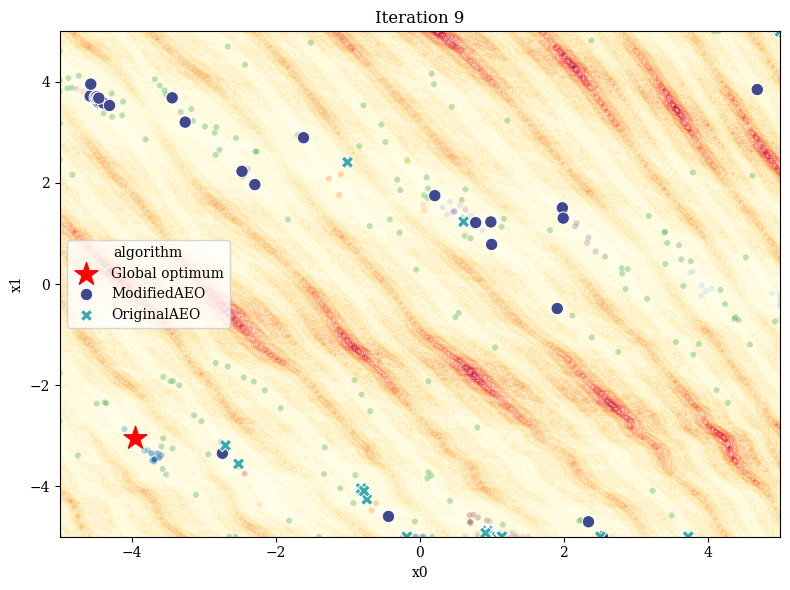

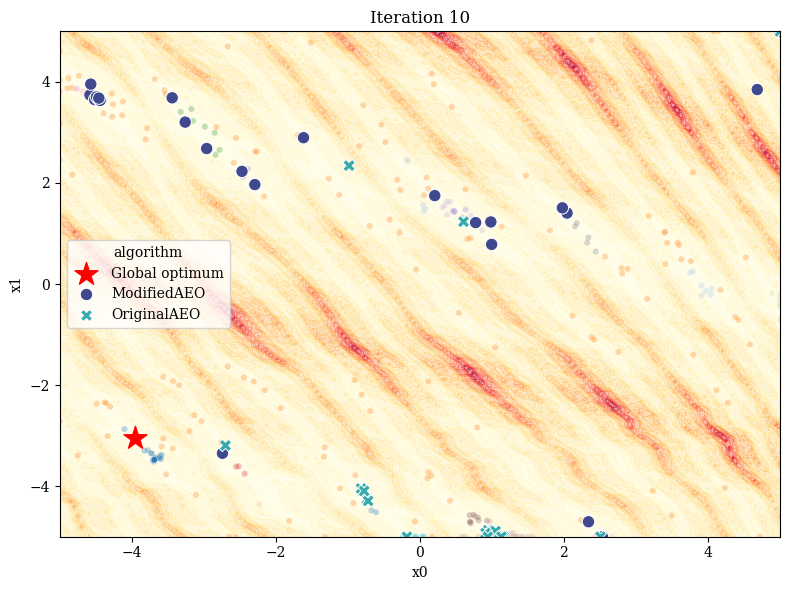

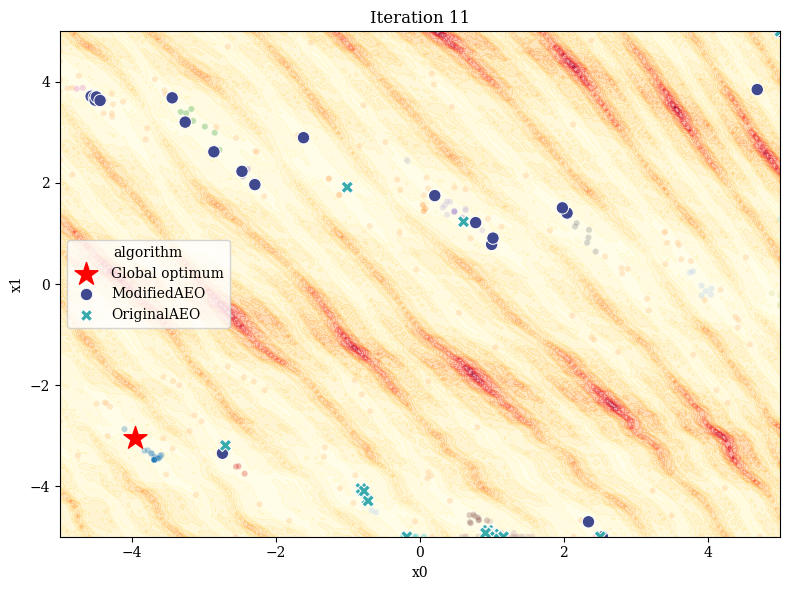

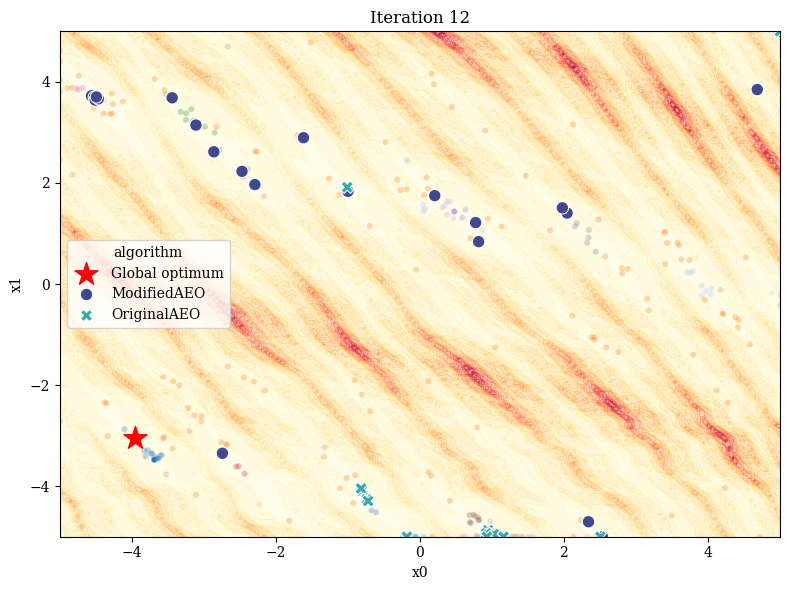

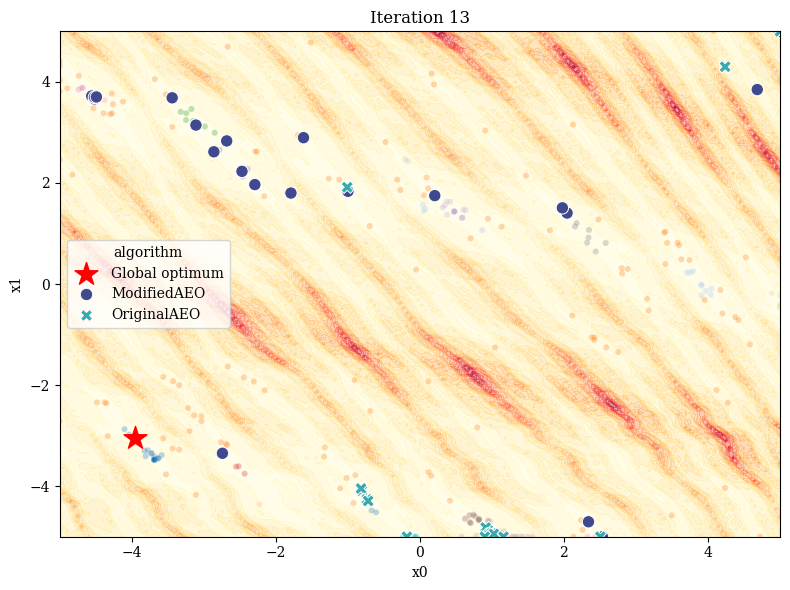

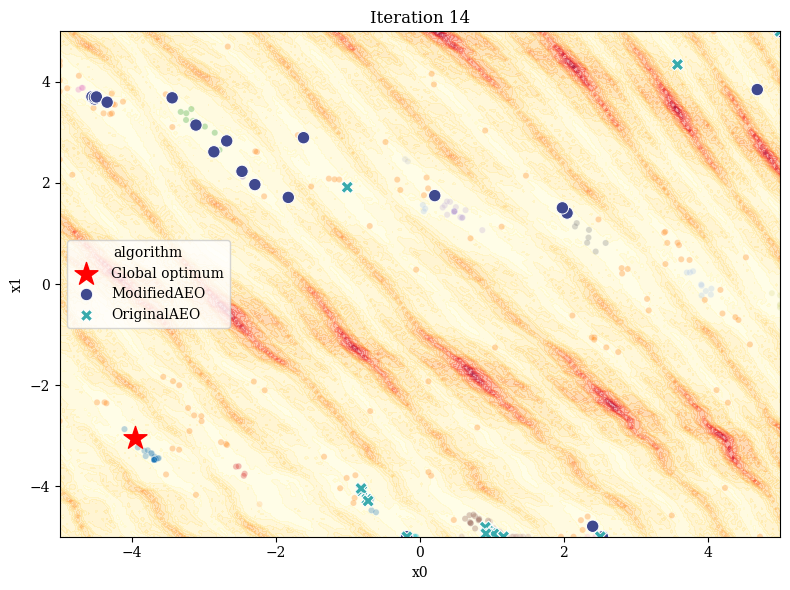

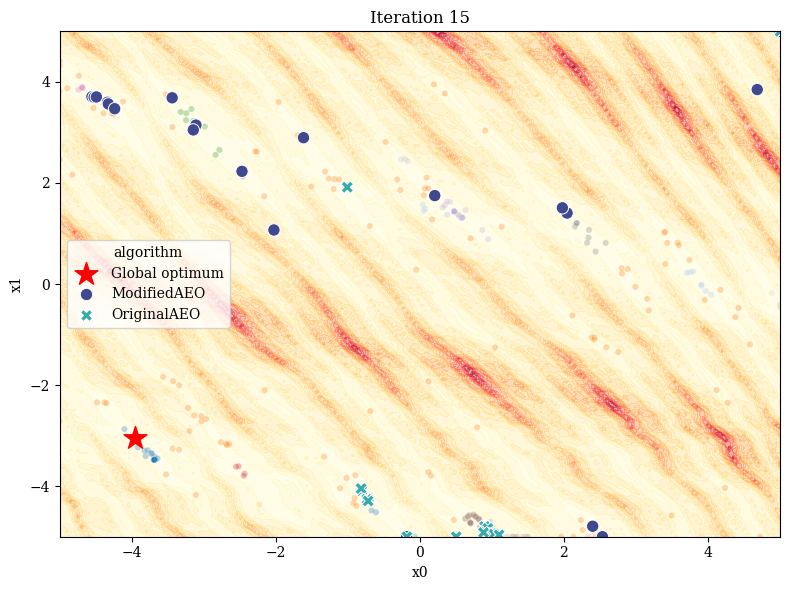

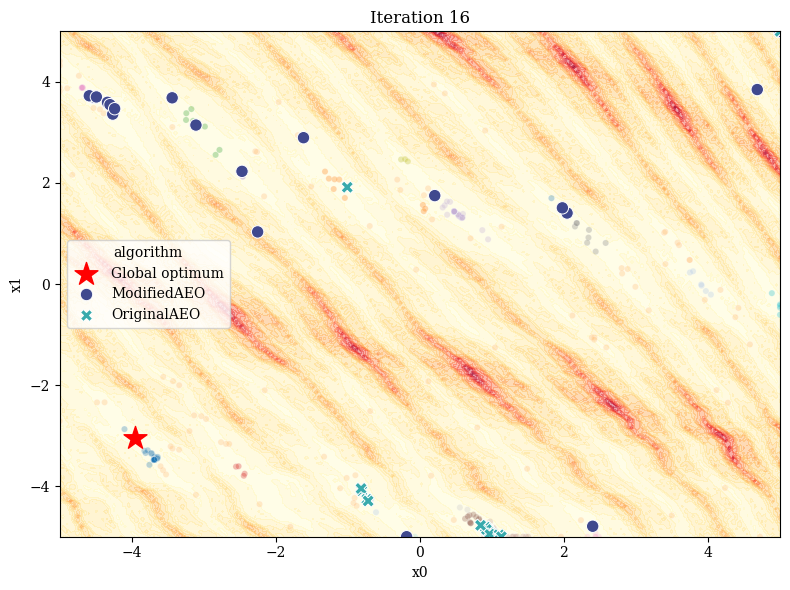

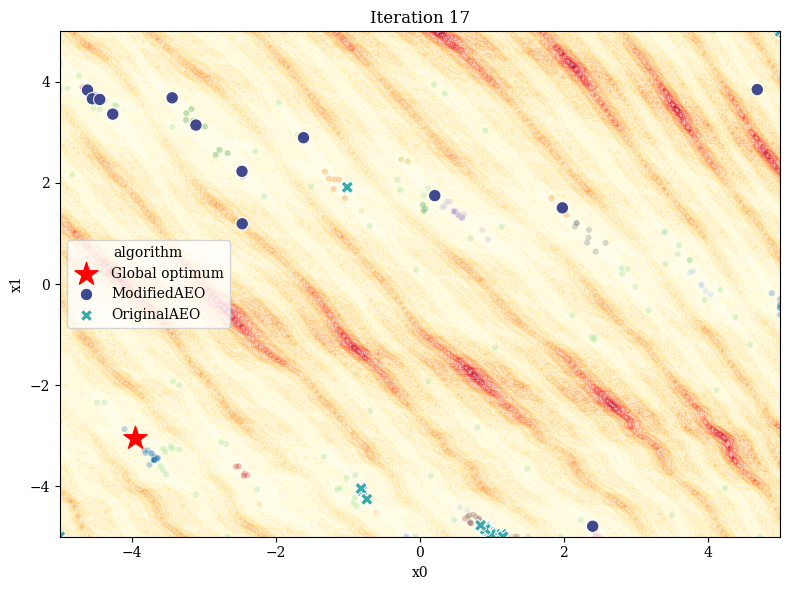

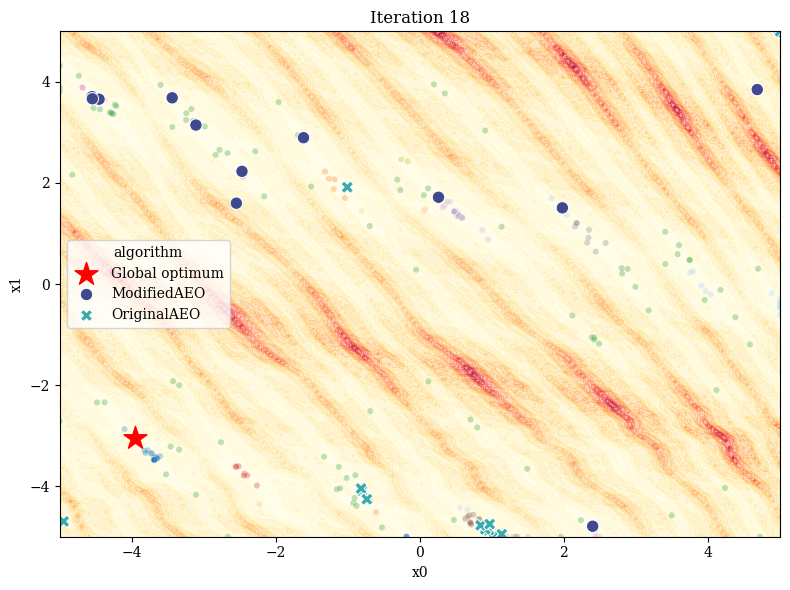

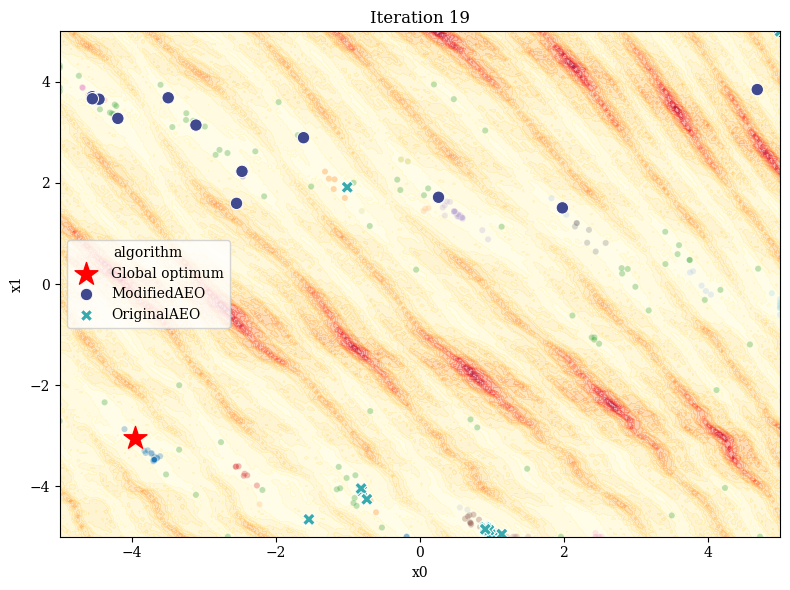

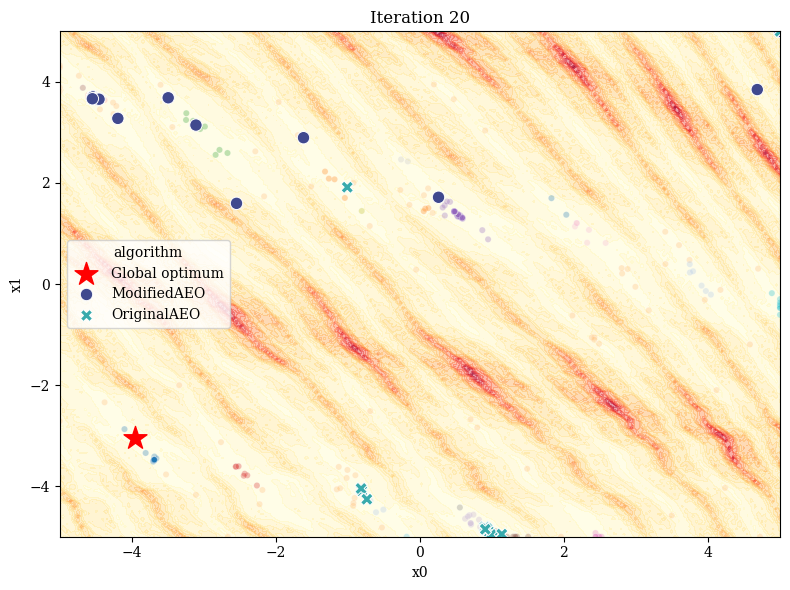

In [43]:
for i in range(1, 21):
    fig, ax = plt.subplots(figsize=(8, 6))
    # Add global optimum to your scatter plot
    opt_x = problem.optimum.x[0]
    opt_y = problem.optimum.x[1]
    n = 200  # grid resolution
    A = np.linspace(problem.bounds.lb[0], problem.bounds.ub[0], n)
    B = np.linspace(problem.bounds.lb[1], problem.bounds.ub[1], n)
    XX, YY = np.meshgrid(A, B)
    plot_problem = get_problem(16, instance=3, dimension=2)
    ZZ = np.array([[plot_problem(np.array([x, y])) for x in A] for y in B])
    ax.contourf(XX, YY, ZZ, levels=20, cmap='YlOrRd', alpha=0.4)
    ax.scatter(problem.optimum.x[0], problem.optimum.x[1], 
            marker='*', s=300, c='red', zorder=5, label='Global optimum')
    ax.legend()
    # Background — all points colored by cluster to show DBSCAN regions
    sns.scatterplot(
        data=d.query('iteration==@i and run==2'),
        x='x0', y='x1',
        hue='cluster',
        palette='tab20',
        alpha=0.3,
        s=20,
        ax=ax,
        legend=False
    )
    
    # Foreground — the two algorithms with distinct markers
    sns.scatterplot(
        data=d.query('run==2 and iteration==@i and algorithm in ["ModifiedAEO","OriginalAEO"]'),
        x='x0', y='x1',
        hue='algorithm',
        palette='mako',
        style='algorithm',
        s=80,
        ax=ax
    )
    
    ax.set_title(f'Iteration {i}')
    plt.tight_layout()
    plt.show() 

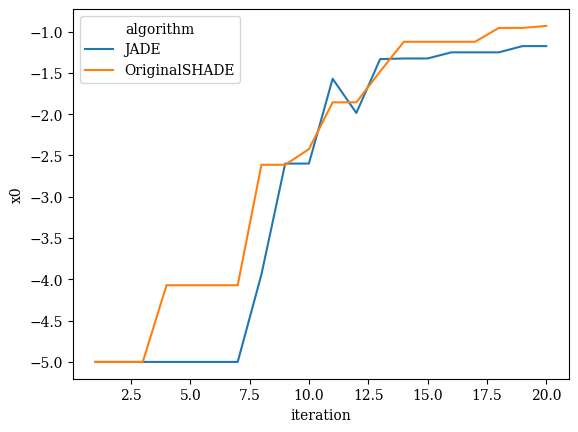

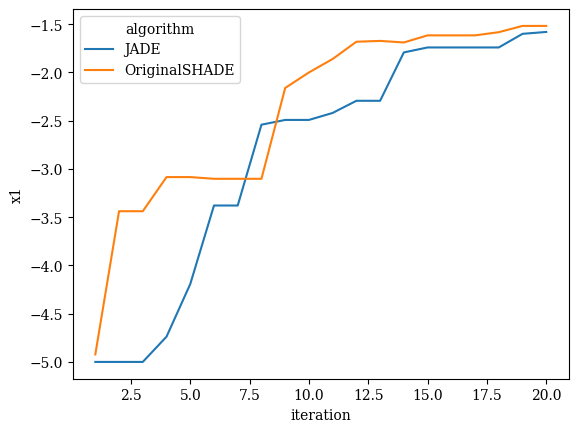

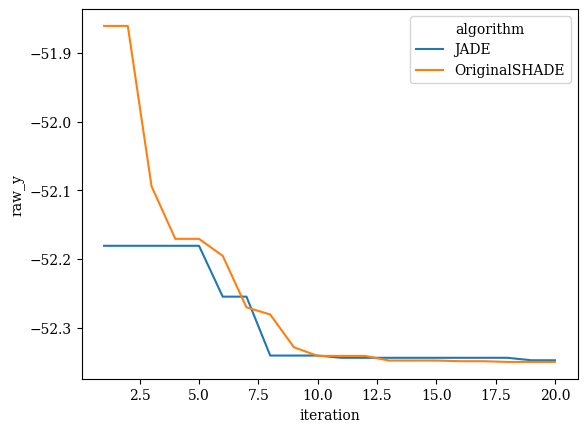

In [14]:
for x in [f'x{i}' for i in range(0,dim)] + ['raw_y']:
    plt.figure()
    tt=d.query('algorithm in ["OriginalSHADE","JADE"] and run==1').groupby(['algorithm','iteration'])[x].min().to_frame()
    sns.lineplot(tt,x='iteration',y=x,hue='algorithm')
    plt.show()